In [1]:
import pandas as pd
df_cash = pd.read_csv("C:/Users/admin/Downloads/datasets/daily_cashflow_dataset.csv")

In [2]:
df_cash.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   date             300000 non-null  str  
 1   inflow_type      300000 non-null  str  
 2   outflow_type     300000 non-null  str  
 3   expected_amount  300000 non-null  int64
 4   actual_amount    300000 non-null  int64
 5   variance         300000 non-null  int64
dtypes: int64(3), str(3)
memory usage: 23.4 MB


In [3]:
total_expected = df_cash["expected_amount"].sum()

In [4]:
total_expected

np.int64(750670303492)

In [5]:
total_actual = df_cash["actual_amount"].sum()

In [6]:
total_actual

np.int64(752477602329)

In [7]:
variance = total_actual - total_expected

In [8]:
variance

np.int64(1807298837)

In [9]:
variance_pct = variance / total_expected

In [10]:
variance_pct

np.float64(0.002407580036925306)

In [11]:
daily_variance = df_cash.groupby("date")["variance"].sum()

avg_daily_variance = daily_variance.mean()

In [12]:
avg_daily_variance

np.float64(1650501.2210045662)

In [13]:
volatility = daily_variance.std()

In [14]:
volatility

np.float64(35070582.72224233)

In [15]:
accuracy_score = 1 - abs(variance_pct)

In [16]:
accuracy_score

np.float64(0.9975924199630747)

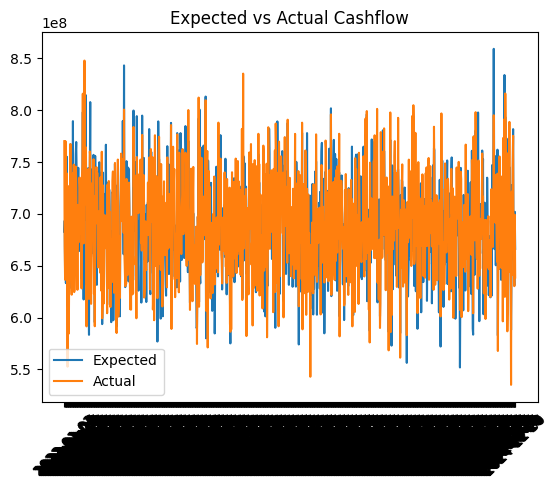

In [27]:
import matplotlib.pyplot as plt

daily = df_cash.groupby("date").agg({
    "expected_amount": "sum",
    "actual_amount": "sum",
    "variance": "sum"
}).reset_index()

plt.figure()
plt.plot(daily["date"], daily["expected_amount"], label="Expected")
plt.plot(daily["date"], daily["actual_amount"], label="Actual")
plt.legend()
plt.title("Expected vs Actual Cashflow")
plt.xticks(rotation=45)
plt.show()

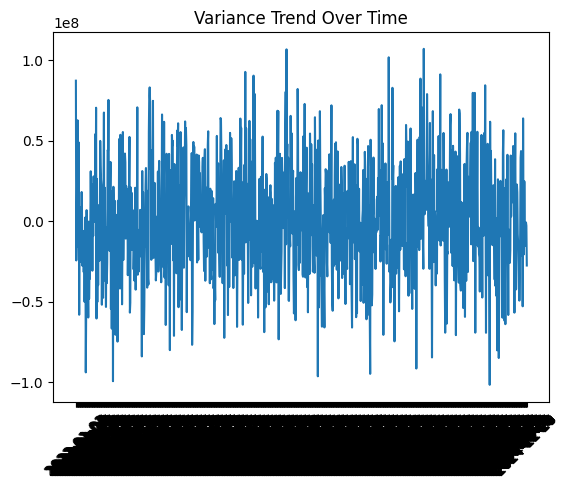

In [25]:
plt.figure()
plt.plot(daily["date"], daily["variance"])
plt.title("Variance Trend Over Time")
plt.xticks(rotation=45)
plt.show()

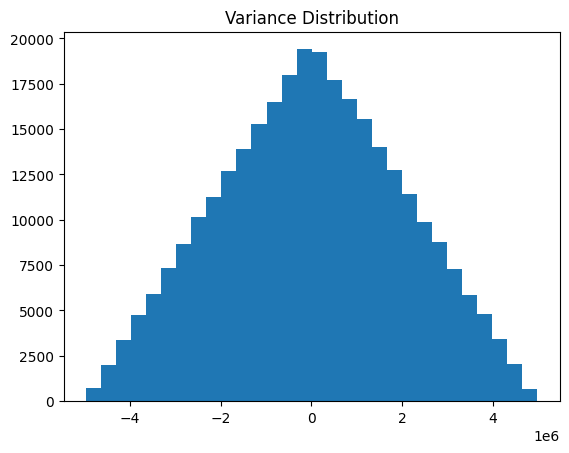

In [28]:
plt.figure()
plt.hist(df_cash["variance"].dropna(), bins=30)
plt.title("Variance Distribution")
plt.show()

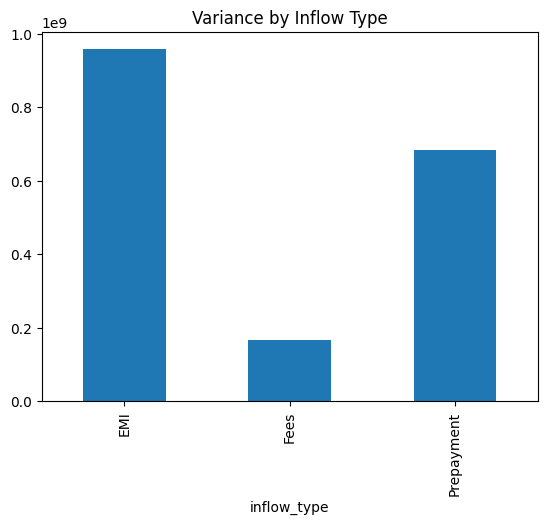

In [31]:
inflow_type = ["EMI", "Prepayment", "Fees"]

inflow_df = df_cash[df_cash["inflow_type"].isin(inflow_type)]

inflow_variance = inflow_df.groupby("inflow_type")["variance"].sum()

plt.figure()
inflow_variance.plot(kind="bar")
plt.title("Variance by Inflow Type")
plt.show()

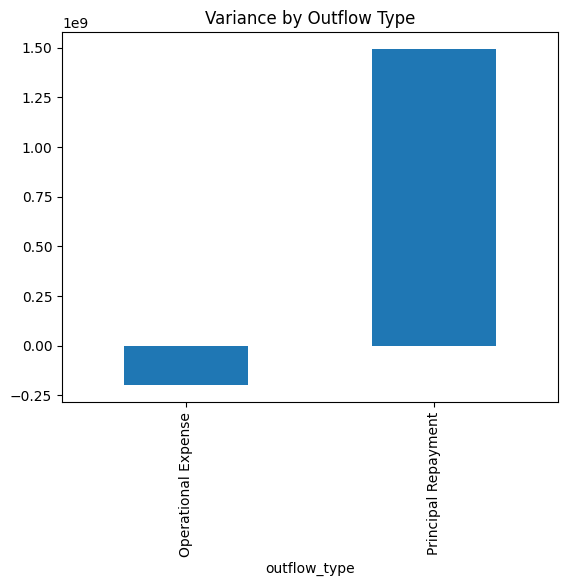

In [24]:
import matplotlib.pyplot as plt
outflow_type = [" Interest Payment", "Operational Expense", "Principal Repayment"]

outflow_df = df_cash[df_cash["outflow_type"].isin(outflow_type)]

outflow_variance = outflow_df.groupby("outflow_type")["variance"].sum()

plt.figure()
outflow_variance.plot(kind="bar")
plt.title("Variance by Outflow Type")
plt.show()

In [21]:
df_cash.columns = df_cash.columns.str.strip().str.lower()

In [22]:

df_cash["variance"]

0         -347259
1          663314
2         3117630
3        -3884040
4        -1939392
           ...   
299995    -164439
299996   -2238108
299997    -217763
299998    2647701
299999   -2353531
Name: variance, Length: 300000, dtype: int64

In [23]:
df_cash["outflow_type"]

0            Interest Payment
1         Operational Expense
2         Principal Repayment
3         Operational Expense
4            Interest Payment
                 ...         
299995       Interest Payment
299996       Interest Payment
299997       Interest Payment
299998       Interest Payment
299999    Operational Expense
Name: outflow_type, Length: 300000, dtype: str

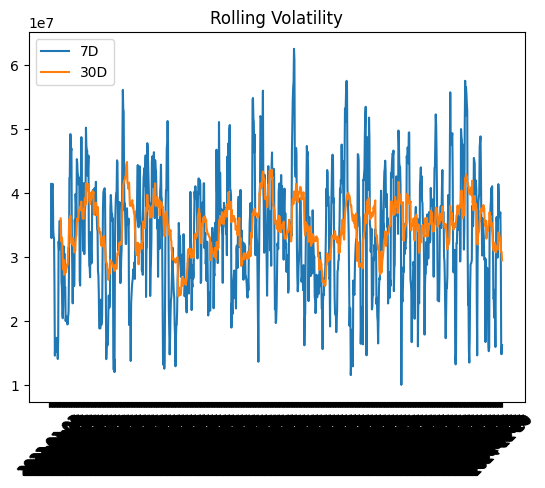

In [34]:
daily["7D Volatility"] = daily["variance"].rolling(7).std()
daily["30D Volatility"] = daily["variance"].rolling(30).std()

plt.figure()
plt.plot(daily["date"], daily["7D Volatility"], label="7D")
plt.plot(daily["date"], daily["30D Volatility"], label="30D")
plt.legend()
plt.title("Rolling Volatility")
plt.xticks(rotation=45)
plt.show()

In [37]:
df_cash["date"] = pd.to_datetime(df_cash["date"], errors="coerce")

In [38]:
df_cash["date"] 

0        2023-07-09
1        2022-01-10
2        2024-09-30
3        2023-10-07
4        2024-05-25
            ...    
299995   2024-12-07
299996   2023-01-05
299997   2024-09-08
299998   2022-07-08
299999   2022-02-22
Name: date, Length: 300000, dtype: datetime64[us]

In [39]:
print(df_cash["date"].dtype)

datetime64[us]


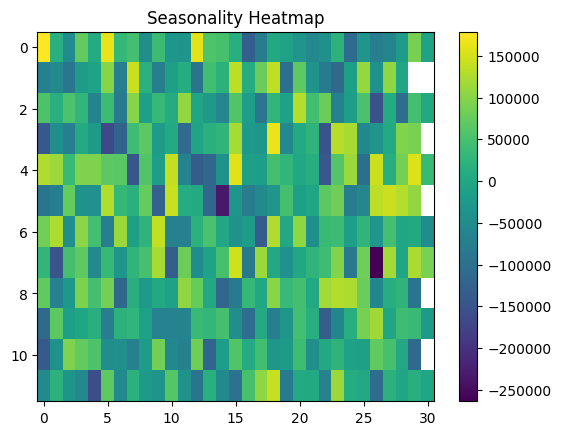

In [41]:
df_cash["month"] = df_cash["date"].dt.month
df_cash["day"] = df_cash["date"].dt.day

heatmap_data = df_cash.pivot_table(
    values="variance",
    index="month",
    columns="day",
    aggfunc="mean"
)

plt.figure()
plt.imshow(heatmap_data, aspect='auto')
plt.title("Seasonality Heatmap")
plt.colorbar()
plt.show()